In [1]:
import numpy as np
import pydosert as pdrt
import pydicom
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from pydosert.data.loaders import load_dicom

# Use GPU when available; otherwise fall back to CPU.
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")
dtype = torch.float32


CT volume (z, y, x): (83, 512, 512)
spacing (x, y, z) mm: (0.5859375, 0.5859375, 2.5)
origin  (x, y, z) mm: (-149.70703125, -149.70703125, -102.5)
HU min / max: -1000.0 / -1000.0


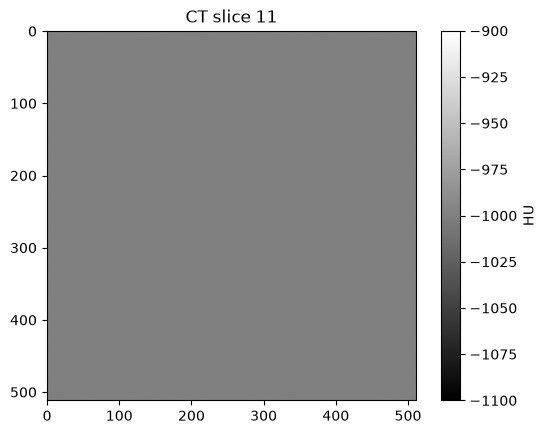

In [2]:
# Load just the CT series from CPPP/CT with pydosert
import SimpleITK as sitk
from pydosert.data.utils.dicom_utils import load_ct_series

ct_image, ct_ref_slice = load_ct_series(Path("CPPP/CT"))

ct_hu = sitk.GetArrayFromImage(ct_image)          # (z, y, x) Hounsfield units
ct_tensor = torch.from_numpy(ct_hu).to(device=device, dtype=dtype)

print("CT volume (z, y, x):", ct_hu.shape)
print("spacing (x, y, z) mm:", ct_image.GetSpacing())
print("origin  (x, y, z) mm:", ct_image.GetOrigin())
print("HU min / max:", float(ct_hu.min()), "/", float(ct_hu.max()))

# quick look at the middle slice
mid = ct_hu.shape[0] // 2 - 30
plt.imshow(ct_hu[mid], cmap="gray")
plt.title(f"CT slice {mid}")
plt.colorbar(label="HU")
plt.show()